# Assignment Two — 2025

## Data Preprocessing
- Simple statistical evaluation of the data set;
- Identify the target variable(s);
- Identify if this is a regression or a classification task;
- Are there any missing data? What can you do about them?
- Which variables are relevant or irrelevant to the task?
- What type of validation/cross-validation procedure will you use? 
- Data visualisation.

In [13]:
# Install Package 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns

In [3]:
# Loading the data
data = pd.read_csv("Euro_6_latest.csv", 
                   encoding= 'latin1') # encoding = 'latin1' is required because in the dataset, 
                                       # there are special characters. Latin1 is an encoding for Western Europe. 
data.head()
# From the data.head() code, we see that there are 45 columns. However, in this dataset, the last column is 'unnamed:44' and there is no values in this column. 
# This is because the last column in the original dataset is 'Date of change' with a comma, thus, the pandas see it as a column and include it. Thus, this last column should be slided out.
# After the initial understanding of the meaning of each column in this dataset, the first three columns 'Manufacturere', 'Model', and 'Description', 'Noise Level dB (A)'


# Moreover, from the initial assessment, as the topic focuses on the car and emission, 'Noise Level dB (A)' is not relevant and it should be also dropped. 
# Similarly, 'Date of Change' column appears simply as an updated date of each row. Hence, it is dropped.

#

,Manufacturer,Model,Description,Transmission,Manual or Automatic,Engine Capacity,Fuel Type,Powertrain,Engine Power (PS),Engine Power (Kw),...,Emissions CO [mg/km],THC Emissions [mg/km],Emissions NOx [mg/km],THC + NOx Emissions [mg/km],Particulates [No.] [mg/km],RDE NOx Urban,RDE NOx Combined,Noise Level dB(A),Date of change,Unnamed: 44
0,ABARTH,500e MY23/24,114kW Electric (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17 October 2024,NaN
1,ABARTH,500e MY23/24,114kW Electric (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17 October 2024,NaN
2,ABARTH,500e MY23/24,114kW Electric Convertible (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17 October 2024,NaN
3,ABARTH,500e MY23/24,114kW Electric Convertible (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17 October 2024,NaN
4,ABARTH,595 MY23,Turismo 1.4 Tjet 165 hp Manual (VL),M5,Manual,1368.0,Petrol,Internal Combustion Engine (ICE),165.0,121.0,...,688.0,66.0,28.0,NaN,NaN,60.0,60.0,69.0,17 October 2024,NaN


In [4]:
data.shape

(3702, 45)

In [5]:
data.dtypes
# only data type for column 'Date of change' is not at the right match while the rest is correct. 

Manufacturer                              object
Model                                     object
Description                               object
Transmission                              object
Manual or Automatic                       object
Engine Capacity                          float64
Fuel Type                                 object
Powertrain                                object
Engine Power (PS)                        float64
Engine Power (Kw)                        float64
Electric energy consumption Miles/kWh    float64
wh/km                                    float64
Maximum range (Km)                       float64
Maximum range (Miles)                    float64
Euro Standard                             object
Diesel VED Supplement                       bool
Testing Scheme                            object
WLTP Imperial Low                        float64
WLTP Imperial Medium                     float64
WLTP Imperial High                       float64
WLTP Imperial Extra 

In [6]:
# Drop 3 the last 3 columns
data = data.drop(columns=["Manufacturer","Model", "Description", "Euro Standard", "Diesel VED Supplement", "Testing Scheme", "Unnamed: 44", "Date of change", "Noise Level dB(A)"], axis = 1)
data.head()

,Transmission,Manual or Automatic,Engine Capacity,Fuel Type,Powertrain,Engine Power (PS),Engine Power (Kw),Electric energy consumption Miles/kWh,wh/km,Maximum range (Km),...,Equivalent All Electric Range KM,Electric Range City Miles,Electric Range City Km,Emissions CO [mg/km],THC Emissions [mg/km],Emissions NOx [mg/km],THC + NOx Emissions [mg/km],Particulates [No.] [mg/km],RDE NOx Urban,RDE NOx Combined
0,A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,3.6,172.0,264.0,...,NaN,223.0,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,3.3,187.0,244.0,...,NaN,205.0,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,3.6,172.0,264.0,...,NaN,223.0,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,3.3,187.0,244.0,...,NaN,205.0,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,M5,Manual,1368.0,Petrol,Internal Combustion Engine (ICE),165.0,121.0,0.0,NaN,NaN,...,NaN,NaN,NaN,688.0,66.0,28.0,NaN,NaN,60.0,60.0


In [7]:
# Count the number of N/A values in each column
number_of_columns = data.shape[1]
for i in range(number_of_columns):
    col_name = data.columns[i]
    count = data[col_name].isna().sum()
    print(f"The number of NA values in column '{col_name}' is {count}")

The number of NA values in column 'Transmission' is 558
The number of NA values in column 'Manual or Automatic' is 0
The number of NA values in column 'Engine Capacity' is 2
The number of NA values in column 'Fuel Type' is 0
The number of NA values in column 'Powertrain' is 0
The number of NA values in column 'Engine Power (PS)' is 19
The number of NA values in column 'Engine Power (Kw)' is 8
The number of NA values in column 'Electric energy consumption Miles/kWh' is 883
The number of NA values in column 'wh/km' is 2516
The number of NA values in column 'Maximum range (Km)' is 2375
The number of NA values in column 'Maximum range (Miles)' is 2702
The number of NA values in column 'WLTP Imperial Low' is 0
The number of NA values in column 'WLTP Imperial Medium' is 0
The number of NA values in column 'WLTP Imperial High' is 0
The number of NA values in column 'WLTP Imperial Extra High' is 0
The number of NA values in column 'WLTP Imperial Combined' is 0
The number of NA values in column

### Statistical Analysis

In [10]:
# Review Mean, Min, Max, SD of data
data.describe()

,Engine Capacity,Engine Power (PS),Engine Power (Kw),Electric energy consumption Miles/kWh,wh/km,Maximum range (Km),Maximum range (Miles),WLTP Imperial Low,WLTP Imperial Medium,WLTP Imperial High,...,Equivalent All Electric Range KM,Electric Range City Miles,Electric Range City Km,Emissions CO [mg/km],THC Emissions [mg/km],Emissions NOx [mg/km],THC + NOx Emissions [mg/km],Particulates [No.] [mg/km],RDE NOx Urban,RDE NOx Combined
count,3700.000000,3683.000000,3694.000000,2819.000000,1186.000000,1327.000000,1000.000000,3702.000000,3702.000000,3702.000000,...,701.000000,997.000000,1317.000000,3430.000000,2805.000000,3060.000000,1084.000000,1454.000000,1865.000000,1864.000000
mean,1457.020000,202.254141,160.312398,1.896595,171.558179,270.663150,215.574000,29.834414,36.915073,39.302728,...,43.754636,281.998997,355.225513,203.393003,18.046346,14.306536,16.828413,0.279684,61.390885,61.470494
std,1039.860432,127.951896,140.140297,3.913432,42.727697,217.607324,122.291667,21.940253,24.854016,25.423989,...,35.970381,158.354937,283.536294,182.095444,13.217321,12.533870,22.736478,0.403570,20.181420,20.238253
min,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,999.000000,129.000000,95.000000,0.000000,156.000000,57.000000,102.750000,0.000000,0.000000,0.000000,...,0.000000,69.000000,64.000000,40.000000,11.000000,6.000000,0.000000,0.040000,60.000000,60.000000
50%,1490.000000,160.000000,120.000000,0.000000,170.000000,333.000000,251.000000,34.400000,44.800000,50.400000,...,54.000000,334.000000,458.000000,165.000000,17.000000,12.000000,0.000000,0.125000,60.000000,60.000000
75%,1993.000000,244.000000,184.000000,3.500000,188.000000,453.500000,296.000000,42.200000,53.300000,57.600000,...,67.000000,400.000000,602.000000,311.000000,24.000000,21.000000,29.000000,0.370000,60.000000,60.000000
max,6749.000000,1267.000000,1200.000000,38.400000,303.000000,820.000000,510.000000,100.900000,97.400000,80.700000,...,199.000000,573.000000,922.000000,918.000000,156.000000,216.000000,124.000000,3.440000,179.000000,179.000000


C:\Users\nbngu\AppData\Local\Temp\ipykernel_18700\2666470185.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = data.corr()


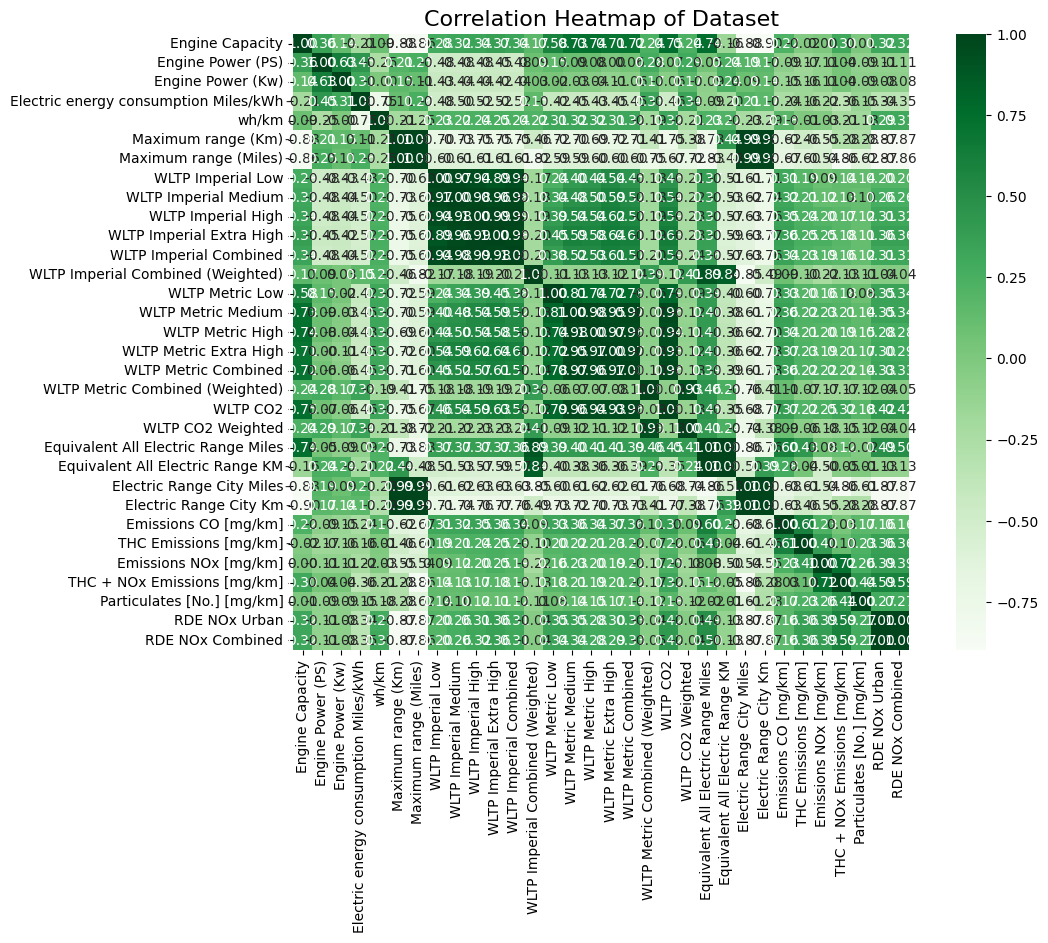

In [17]:
# compute correlation matrix
corr = data.corr()

# set plot size
plt.figure(figsize=(12,8))

# create heatmap
sns.heatmap(corr, 
            annot=True,      # show correlation values in cells
            fmt=".2f",       # format numbers (2 decimals)
            cmap="Greens",  # color map: blue→red
            cbar=True,       # show color bar
            square=True)     # keep cells square

plt.title("Correlation Heatmap of Dataset", fontsize=16)
plt.show()

array([[<Axes: title={'center': 'Engine Capacity'}>,
        <Axes: title={'center': 'Engine Power (PS)'}>,
        <Axes: title={'center': 'Engine Power (Kw)'}>,
        <Axes: title={'center': 'Electric energy consumption Miles/kWh'}>,
        <Axes: title={'center': 'wh/km'}>,
        <Axes: title={'center': 'Maximum range (Km)'}>],
       [<Axes: title={'center': 'Maximum range (Miles)'}>,
        <Axes: title={'center': 'WLTP Imperial Low'}>,
        <Axes: title={'center': 'WLTP Imperial Medium'}>,
        <Axes: title={'center': 'WLTP Imperial High'}>,
        <Axes: title={'center': 'WLTP Imperial Extra High'}>,
        <Axes: title={'center': 'WLTP Imperial Combined'}>],
       [<Axes: title={'center': 'WLTP Imperial Combined (Weighted)'}>,
        <Axes: title={'center': 'WLTP Metric Low'}>,
        <Axes: title={'center': 'WLTP Metric Medium'}>,
        <Axes: title={'center': 'WLTP Metric High'}>,
        <Axes: title={'center': 'WLTP Metric Extra High'}>,
        <Axes: ti

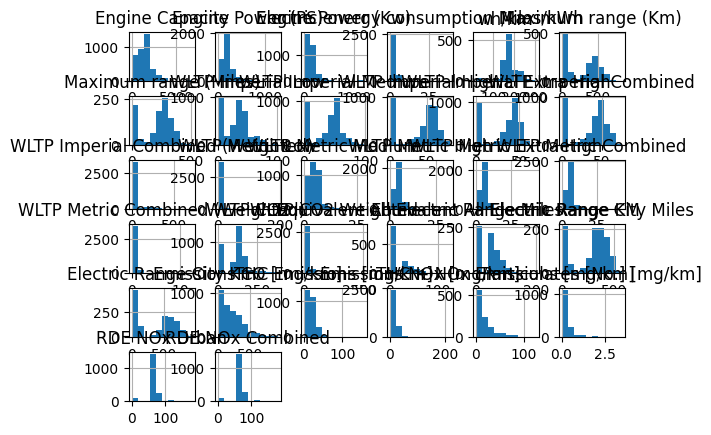

In [20]:
data.hist()